# NBA Players stats(2023 season)
### 2022-2023的 82 場例行賽
[點我看網站](https://www.kaggle.com/datasets/amirhosseinmirzaie/nba-players-stats2023-season)

## Position與進攻、防守的關係
- 

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [242]:
data = pd.read_csv('2023nba.csv')

In [243]:
data.head()

,PName,POS,Team,Age,GP,W,L,Min,PTS,FGM,...,TD3,Plus/Minus,PPG,RPG,APG,TOPG,SPG,BPG,FPG,TS%
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,1,470,30.07,8.77,4.62,2.88,1.05,0.69,2.16,60.70
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,1,424,33.08,10.15,4.15,3.42,1.00,1.70,3.11,65.47
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,10,128,32.39,8.62,8.02,3.58,1.36,0.50,2.52,60.93
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,0,149,31.40,4.84,5.46,2.82,1.65,0.96,2.82,62.57
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,6,341,31.10,11.78,5.70,3.90,0.83,0.81,3.13,60.55


| G | SG | PG | F | SF | PF | C |
|----|---|----|----|----|---|---|
| Guard | Shooting_Guard | Point_Guard | Forward | Small_Forward | Power_Forward | Center |
| 後衛 | 得分後衛 | 控球後衛 | 前鋒 | 小前鋒 | 大前鋒 | 中鋒 |

In [244]:
data.rename(columns={
    'PName': 'Player_Name',
    'POS': 'Position',
    'Team': 'Team_Abbreviation',
    'Age': 'Age',
    'GP': 'Games_Played',
    'W': 'Wins',
    'L': 'Losses',
    'Min': 'Minutes_Played',
    'PTS': 'Total_Points',
    'FGM': 'Field_Goal_Made',
    'FGA': 'Field_Goal_Attempted',
    'FG%': 'Field_Goal_Percentage',
    '3PM': 'Three_Point_Made',
    '3PA': 'Three_Point_Attempted',
    '3P%': 'Three_Point_Percentage',
    'FTM': 'Free_Throw_Made',
    'FTA': 'Free_Throw_Attempted',
    'FT%': 'Free_Throw_Percentage',
    'OREB': 'Offensive_Rebounds',
    'DREB': 'Defensive_Rebounds',
    'REB': 'Total_Rebounds',
    'AST': 'Assists',
    'TOV': 'Turnovers',
    'STL': 'Steals',
    'BLK': 'Blocks',
    'PF': 'Personal_Fouls',
    'FP': 'NBA_Fantasy_Points',
    'DD2': 'Double_Doubles',
    'TD3': 'Triple_Doubles',
    '+/-': 'Plus_Minus',
    'PPG': 'Points_Per_Game',
    'RPG': 'Rebounds_Per_Game',
    'APG' :'Assists_Per_Game',
    'TOPG' :'Turnovers_Per_Game',
    'SPG' :'Steals_Per_Game',
    'BPG' :'Blocks_Per_Game',
    'FPG' :'Fouls_Per_Game',
    'TS%' :'True_Shooting_Percentage'
}, inplace=True)

## 欄位說明
[參考](https://www.basketball-reference.com/about/glossary.html#fg)

| 原始欄位 | 英文說明欄位 | 中文解釋 |
|---------|--------------|----------|
| PName   | Player_Name | 球員姓名 |
| POS     | Position | 場上位置 |
| Team    | Team_Abbreviation | 球隊縮寫 |
| Age     | Age | 年齡 |
| GP      | Games_Played | 出賽場次 |
| W       | Wins | 勝場 |
| L       | Losses | 敗場 |
| Min     | Minutes_Played | 上場時間（分鐘） |
| PTS     | Total_Points | 總得分 |
| FGM     | Field_Goal_Made | 投籃命中數 |
| FGA     | Field_Goal_Attempted | 投籃出手數 |
| FG%     | Field_Goal_Percentage | 投籃命中率 |
| 3PM     | Three_Point_Made | 三分命中數 |
| 3PA     | Three_Point_Attempted | 三分出手數 |
| 3P%     | Three_Point_Percentage | 三分命中率 |
| FTM     | Free_Throw_Made | 罰球命中數 |
| FTA     | Free_Throw_Attempted | 罰球出手數 |
| FT%     | Free_Throw_Percentage | 罰球命中率 |
| OREB    | Offensive_Rebounds | 進攻籃板 |
| DREB    | Defensive_Rebounds | 防守籃板 |
| REB     | Total_Rebounds | 總籃板 |
| AST     | Assists | 助攻 |
| TOV     | Turnovers | 失誤 |
| STL     | Steals | 抄截 |
| BLK     | Blocks | 阻攻（火鍋） |
| PF      | Personal_Fouls | 犯規 |
| FP      | NBA_Fantasy_Points | NBA Fantasy 積分 |
| DD2     | Double_Doubles | 「雙十」次數 |
| TD3     | Triple_Doubles | 「大三元」次數 |
| +/-     | Plus_Minus | 場上正負值 |
| PPG     | Points Per Game | 場均得分 |
| RPG     | Rebounds Per Game | 場均籃板 |
| APG     | Assists Per Game | 場均助攻 |
| TOPG    | Turnovers Per Game | 場均失誤 |
| SPG     | Steals Per Game | 場均抄截 |
| BPG     | Blocks Per Game | 場均蓋冒 | 
| FPG     | Fouls Per Game | 場均犯規 |
| TS%     | True Shooting Percentage | 真實命中率 | 

### How to calculate the fantasy points
- Three Point Field Goals: 3 points
- Two Point Field Goals: 2 points
- Free Throws Made: 1 point
- Rebounds: 1.2 points
- Assists: 1.5 points
- Blocked Shots: 2 points
- Steals: 2 points
- Turnovers: -1 points


In [245]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Player_Name               539 non-null    object 
 1   Position                  539 non-null    object 
 2   Team_Abbreviation         539 non-null    object 
 3   Age                       539 non-null    int64  
 4   Games_Played              539 non-null    int64  
 5   Wins                      539 non-null    int64  
 6   Losses                    539 non-null    int64  
 7   Minutes_Played            539 non-null    float64
 8   Total_Points              539 non-null    int64  
 9   Field_Goal_Made           539 non-null    int64  
 10  Field_Goal_Attempted      539 non-null    int64  
 11  Field_Goal_Percentage     539 non-null    float64
 12  Three_Point_Made          539 non-null    int64  
 13  Three_Point_Attempted     539 non-null    int64  
 14  Three_Poin

In [246]:
data.duplicated().sum()

0

In [247]:
data.isna().sum()

Player_Name                 0
Position                    0
Team_Abbreviation           0
Age                         0
Games_Played                0
Wins                        0
Losses                      0
Minutes_Played              0
Total_Points                0
Field_Goal_Made             0
Field_Goal_Attempted        0
Field_Goal_Percentage       0
Three_Point_Made            0
Three_Point_Attempted       0
Three_Point_Percentage      0
Free_Throw_Made             0
Free_Throw_Attempted        0
Free_Throw_Percentage       0
Offensive_Rebounds          0
Defensive_Rebounds          0
Total_Rebounds              0
Assists                     0
Turnovers                   0
Steals                      0
Blocks                      0
Personal_Fouls              0
NBA_Fantasy_Points          0
Double_Doubles              0
Triple_Doubles              0
Plus/Minus                  0
Points_Per_Game             0
Rebounds_Per_Game           0
Assists_Per_Game            0
Turnovers_

### FieldGoalPerGame

In [248]:
data['Field_Goal_Attempted_Per_Game'] = data['Field_Goal_Attempted']/data['Games_Played'].where(data['Games_Played']>0, 0)

data['Field_Goal_Made_Per_Game'] = data['Field_Goal_Made']/data['Games_Played'].where(data['Games_Played']>0, 0)

### Rebouns

In [249]:
data['Offensive_Rebounds_Per_Game'] = (data['Offensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0, 0)
data['Offensive_Rebounds_Percentage'] = (data['Offensive_Rebounds']/(data['Offensive_Rebounds']+data['Defensive_Rebounds'])).where(data['Games_Played']>0, 0)

data['Defensive_Rebounds_Per_Game'] = (data['Defensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0, 0)
data['Defensive_Rebounds_Percentage'] = (data['Defensive_Rebounds']/(data['Offensive_Rebounds']+data['Defensive_Rebounds'])).where(data['Games_Played']>0, 0)


### TeamData

In [250]:
team_data = (data.groupby("Team_Abbreviation").agg(Team_FGA=("Field_Goal_Attempted", "sum"), Team_FTA=("Free_Throw_Attempted", "sum"), 
                                                  Team_TOV=("Turnovers", "sum"), Team_MP =("Minutes_Played", "sum"), Team_FGM=('Field_Goal_Made', 'sum')))
data = data.merge(team_data, on="Team_Abbreviation", how="left")

### TwoPoints

In [251]:
data["Two_Point_Made"] = data["Field_Goal_Made"]-data["Three_Point_Made"]
data['Two_Point_Made_Per_Game'] = data["Two_Point_Made"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data["Two_Point_Attempted"] = data["Field_Goal_Attempted"]-data["Three_Point_Attempted"]
data['Two_Point_Attempted_Per_Game'] = data["Two_Point_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)
data['Two_Point_Attempted_Rate'] = (100*data["Two_Point_Attempted"]/data['Field_Goal_Attempted']).where(data["Field_Goal_Attempted"]>0, 0)

data["Two_Point_Percentage"] = (100*data["Two_Point_Made"]/data["Two_Point_Attempted"]).where(data["Two_Point_Attempted"]>0, 0)

### ThreePoints

In [252]:
data['Three_Point_Made_Per_Game'] = data["Three_Point_Made"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data['Three_Point_Attempted_Per_Game'] = data["Three_Point_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data['Three_Point_Attempted_Rate'] = (100*data["Three_Point_Attempted"]/data['Field_Goal_Attempted']).where(data["Field_Goal_Attempted"]>0, 0)


### FreeThrowPerGame

In [253]:
data['Free_Throw_Attempted_Per_Game'] = data["Free_Throw_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

### MinutesPlayedPerGame

In [254]:
data['Minutes_Played_Per_Game'] = data['Minutes_Played'] / data['Games_Played'].where(data["Games_Played"]>0, 0)

### Assists/TurnoverRate

In [255]:
data['Assists/Turnover_Percentage'] = (100*data['Assists']/data['Turnovers']).where(data['Turnovers']>0, 0)

### BlocksPerGame

In [256]:
data["Blocks_Per_Game"] = data["Blocks"] / data["Games_Played"]

### TS%

In [257]:
data['True_Shooting_Percentage'] = pd.to_numeric(data['True_Shooting_Percentage'], errors='coerce')
data['True_Shooting_Percentage'] = data['True_Shooting_Percentage'].fillna(0)

### Usage%

In [258]:
son =  ((data['Field_Goal_Attempted']+0.44*data['Free_Throw_Attempted']+data['Turnovers'])*(data['Team_MP']/5))
mom = data["Minutes_Played"]*(data["Team_FGA"]+0.44*data["Team_FTA"]+data["Team_TOV"])
data['Usage_Percentage'] = (100*son/mom).where(mom>0, 0)

### eFG%

In [259]:
data['Effective_Field_Goal_Percentage'] = (100*((data['Field_Goal_Made']+0.5*data['Three_Point_Made'])/data['Field_Goal_Attempted'])).where(data["Field_Goal_Attempted"]>0, 0)

### AST%

In [260]:
mom2 = (((data['Minutes_Played']/(data['Team_MP']/5))*data['Team_FGM']))-data['Field_Goal_Made']
data['Assists_Percentage'] = (100*data['Assists']/mom2).where(mom2>0, 0)

### TOV%

In [261]:
mom3 = data['Field_Goal_Attempted']+0.44*data['Free_Throw_Attempted']+data['Turnovers']
data['Turnovers_Percentage'] = (100*data['Turnovers'])/mom3.where(mom3>0, 0)

---

In [262]:
data.describe()

,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,Field_Goal_Attempted,Field_Goal_Percentage,Three_Point_Made,...,Three_Point_Made_Per_Game,Three_Point_Attempted_Per_Game,Three_Point_Attempted_Rate,Free_Throw_Attempted_Per_Game,Minutes_Played_Per_Game,Assists/Turnover_Percentage,Usage_Percentage,Effective_Field_Goal_Percentage,Assists_Percentage,Turnovers_Percentage
count,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,...,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,538.000000
mean,25.970315,48.040816,24.018553,24.022263,1103.617625,523.426716,191.576994,403.005566,46.325232,56.324675,...,0.990038,2.782890,40.029688,1.855938,19.796567,181.915965,18.574018,53.187150,13.467328,12.593740
std,4.315513,24.650686,14.496366,13.445866,827.765114,498.084360,178.351286,369.595909,10.967271,60.916821,...,0.872909,2.243816,21.981050,1.880296,9.541295,112.453207,5.825914,10.618800,8.671406,6.922353
min,19.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,30.500000,12.000000,14.000000,329.000000,120.500000,45.500000,93.500000,41.650000,5.000000,...,0.316986,1.000000,25.993266,0.629123,12.452484,115.000000,14.394007,49.441898,7.274880,9.448659
50%,25.000000,54.000000,25.000000,25.000000,970.200000,374.000000,138.000000,300.000000,45.500000,36.000000,...,0.789474,2.365385,40.838852,1.225000,19.185185,166.666667,17.847983,53.773585,11.082953,11.852746
75%,29.000000,68.000000,36.000000,34.000000,1845.900000,769.500000,283.500000,598.500000,50.600000,92.000000,...,1.489512,4.097619,54.694057,2.407077,28.346682,229.814815,21.428119,57.619444,17.679265,15.025182
max,42.000000,83.000000,57.000000,60.000000,2963.200000,2225.000000,728.000000,1559.000000,100.000000,301.000000,...,4.875000,11.410714,100.000000,12.253968,40.800000,1100.000000,49.082544,100.000000,48.812111,100.000000


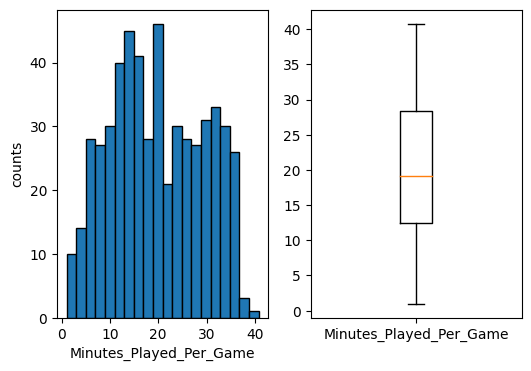

In [263]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax = ax.flatten()
ax[0].hist(data['Minutes_Played_Per_Game'], bins=20, edgecolor='k')
ax[0].set_xlabel('Minutes_Played_Per_Game')
ax[0].set_ylabel('counts')

ax[1].boxplot(data['Minutes_Played_Per_Game'], labels=['Minutes_Played_Per_Game'])

plt.show()

In [264]:
df = data[data['Minutes_Played_Per_Game'] > 19].reset_index(drop=True)
df.shape

(275, 65)

In [265]:
df.replace({'Position': {'PG': 'G', 'SG': 'G', 'SF': 'F', 'PF': 'F'}}, inplace=True)

<Axes: xlabel='Position', ylabel='Count'>

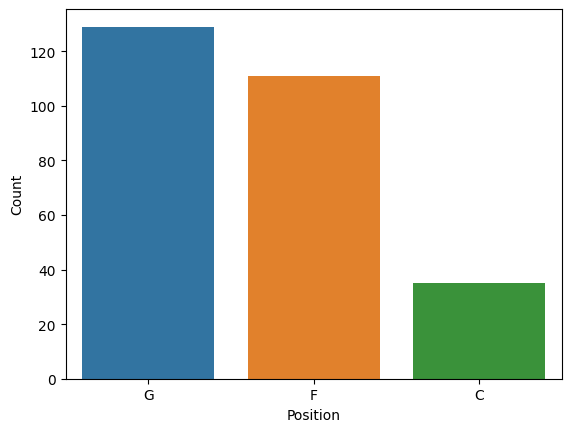

In [266]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

sns.barplot(data=position_counts, x='Position', y='Count', hue='Position')

In [295]:
# position_counts = df['Position'].value_counts().reset_index()
# position_counts.columns = ['Position', 'Count']

# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# ax = ax.flatten()
# sns.histplot(data=df['Minutes_Played_Per_Game'], kde=True, bins=20, ax=ax[0], color='k', alpha=0.3)
# ax[0].set_xlabel("MPg")
# ax[0].set_ylabel("Count")

# sns.boxplot(data=df, x='Minutes_Played_Per_Game', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
# ax[1].set_xlabel("MPg")
# ax[1].set_ylabel("Position")

# positions=['G', 'F', 'C']
# colors = {'G': None, 'F': 'orange', 'C': 'green'}

# positions = ['G', 'F', 'C']
# colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}
# fig, axes = plt.subplots(3, 1, figsize=(15, 10))  # 建立 3×1 子圖

# for idx, pos in enumerate(positions):
#     sub = df[df['Position'] == pos].sort_values(by='Minutes_Played_Per_Game', ascending=False).head(15)
#     sns.barplot(x='Player_Name', y='Minutes_Played_Per_Game', data=sub, ax=axes[idx], color=colors[pos])
#     axes[idx].set_title(f"Position: {pos} — Top 30 Players by MPg")
#     axes[idx].set_ylabel('MPg')
#     axes[idx].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

## Offensive
[Offensive Overview](https://cleaningtheglass.com/stats/guide/player_offensive_overview)

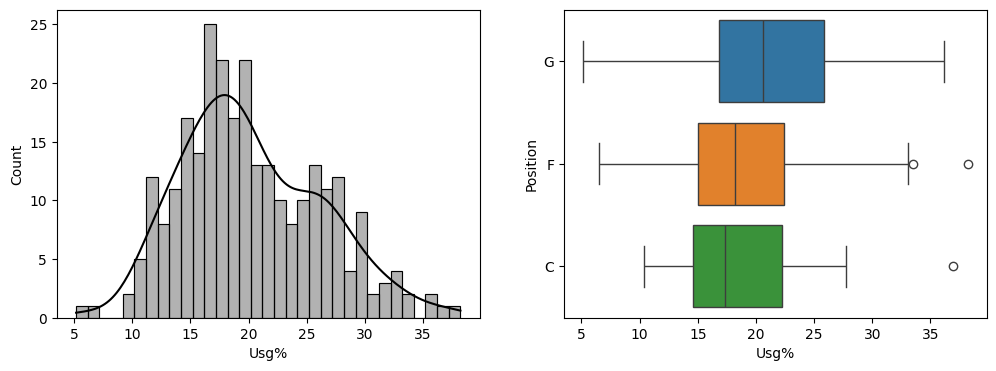

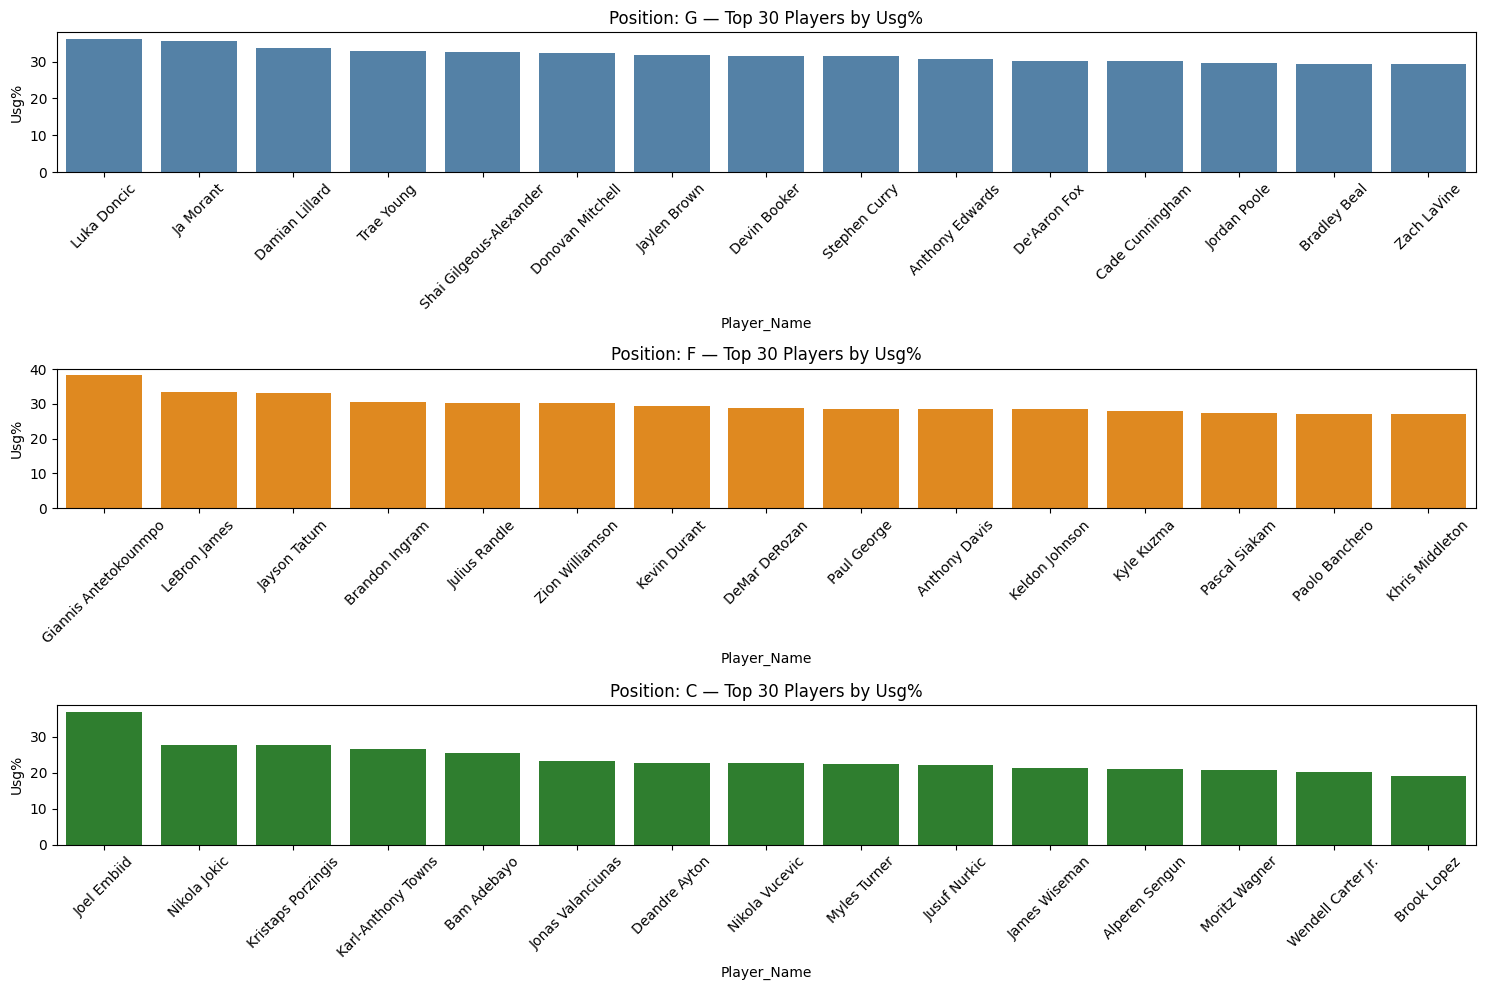

In [268]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

sns.histplot(df['Usage_Percentage'], kde=True, binwidth=1, ax=ax[0], color='k', alpha=0.3)
ax[0].set_xlabel("Usg%")
ax[0].set_ylabel("Count")

sns.boxplot(data=df, x='Usage_Percentage', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
ax[1].set_xlabel("Usg%")
ax[1].set_ylabel("Position")

positions = ['G', 'F', 'C']
colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}
fig, axes = plt.subplots(3, 1, figsize=(15, 10))  # 建立 3×1 子圖

for idx, pos in enumerate(positions):
    sub = df[df['Position'] == pos].sort_values(by='Usage_Percentage', ascending=False).head(15)
    sns.barplot(x='Player_Name', y='Usage_Percentage', data=sub, ax=axes[idx], color=colors[pos])
    axes[idx].set_title(f"Position: {pos} — Top 30 Players by Usg%")
    axes[idx].set_ylabel('Usg%')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

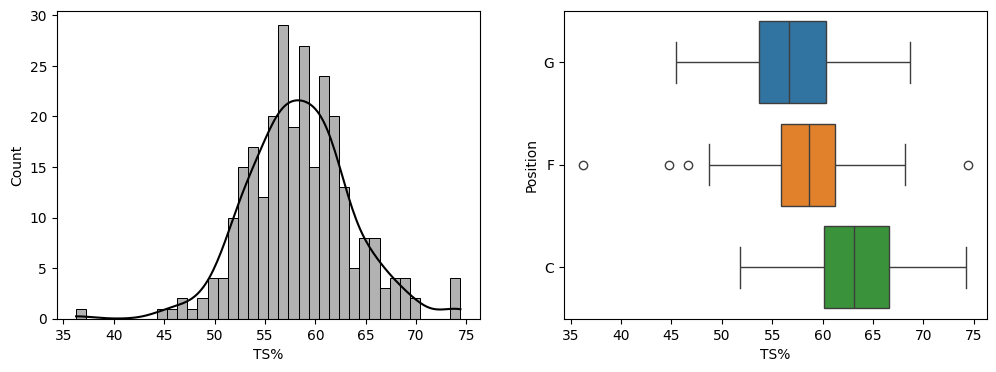

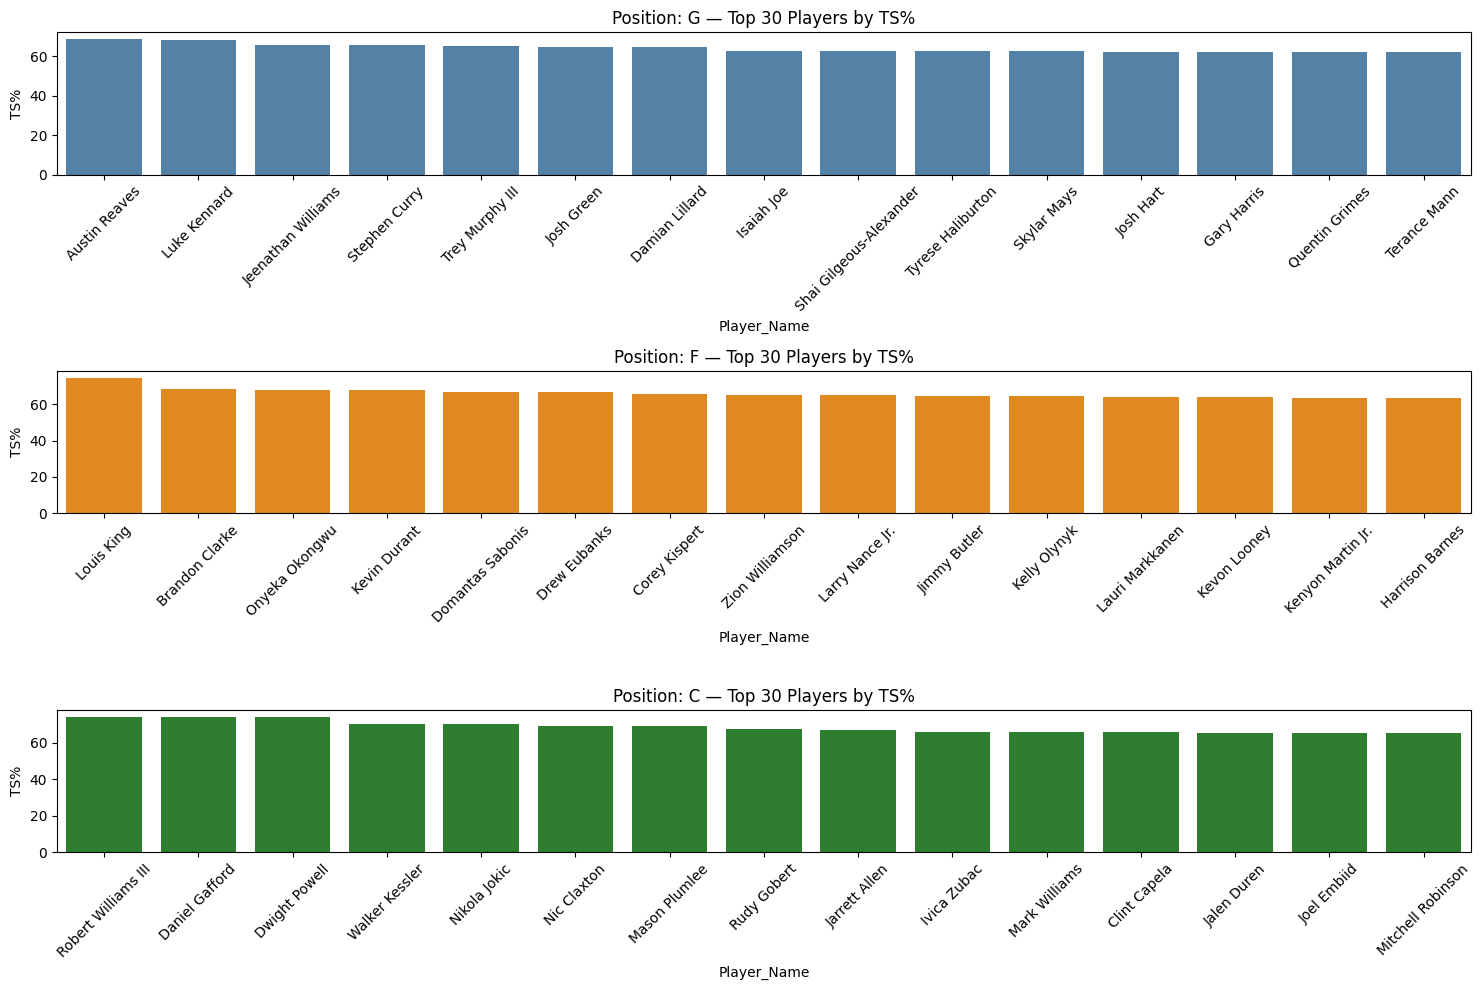

In [269]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

sns.histplot(df['True_Shooting_Percentage'], kde=True, binwidth=1, ax=ax[0], color='k', alpha=0.3)
ax[0].set_xlabel("TS%")
ax[0].set_ylabel("Count")

sns.boxplot(data=df, x='True_Shooting_Percentage', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
ax[1].set_xlabel("TS%")
ax[1].set_ylabel("Position")

positions = ['G', 'F', 'C']
colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}
fig, axes = plt.subplots(3, 1, figsize=(15, 10))  # 建立 3×1 子圖

for idx, pos in enumerate(positions):
    sub = df[df['Position'] == pos].sort_values(by='True_Shooting_Percentage', ascending=False).head(15)
    sns.barplot(x='Player_Name', y='True_Shooting_Percentage', data=sub, ax=axes[idx], color=colors[pos])
    axes[idx].set_title(f"Position: {pos} — Top 30 Players by TS%")
    axes[idx].set_ylabel('TS%')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [293]:
Offensive_df = df[['Position', 'Points_Per_Game', 'Field_Goal_Attempted_Per_Game', 'True_Shooting_Percentage', 'Effective_Field_Goal_Percentage', 'Usage_Percentage', 'Turnovers_Percentage', 'Assists_Percentage',
                   'Assists_Per_Game', 'Turnovers_Per_Game', 'Assists/Turnover_Percentage', 'Offensive_Rebounds_Per_Game', 'Offensive_Rebounds_Percentage',
                   'Three_Point_Attempted_Per_Game', 'Three_Point_Percentage', 'Two_Point_Attempted_Per_Game', 'Two_Point_Percentage', 'Free_Throw_Attempted_Per_Game', 'Free_Throw_Percentage']]
Offensive_df.rename(columns={'Points_Per_Game':'PPg', 'Field_Goal_Attempted_Per_Game':'FGAg', 'Three_Point_Attempted_Per_Game':'3PAg',
                             'Two_Point_Attempted_Per_Game':'2PAg', 'Free_Throw_Attempted_Per_Game':"FTAg",
                             'Free_Throw_Percentage':'FT%','Three_Point_Percentage':'3P%', 'Two_Point_Percentage':'2P%', 'Usage_Percentage':"USG%", 'Turnovers_Per_Game':'TOVg',
                             'Assists/Turnover_Percentage':'AST/TOC%', 'Assists_Per_Game':"ASTg", 'True_Shooting_Percentage':'TS%', 'Turnovers_Percentage':'TOV%', 'Assists_Percentage':'AST%',
                             'Effective_Field_Goal_Percentage':'eFG%', 'Offensive_Rebounds_Per_Game':'ORg', 'Offensive_Rebounds_Percentage':'OR%'}, inplace=True)
# plt.figure(figsize=(10, 10))
# sns.pairplot(Offensive_df, hue='Position', hue_order=['G', 'F', 'C'], height=1.5)
# plt.tight_layout()
# plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_9892\2263400162.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Offensive_df.rename(columns={'Points_Per_Game':'PPg', 'Field_Goal_Attempted_Per_Game':'FGAg', 'Three_Point_Attempted_Per_Game':'3PAg',


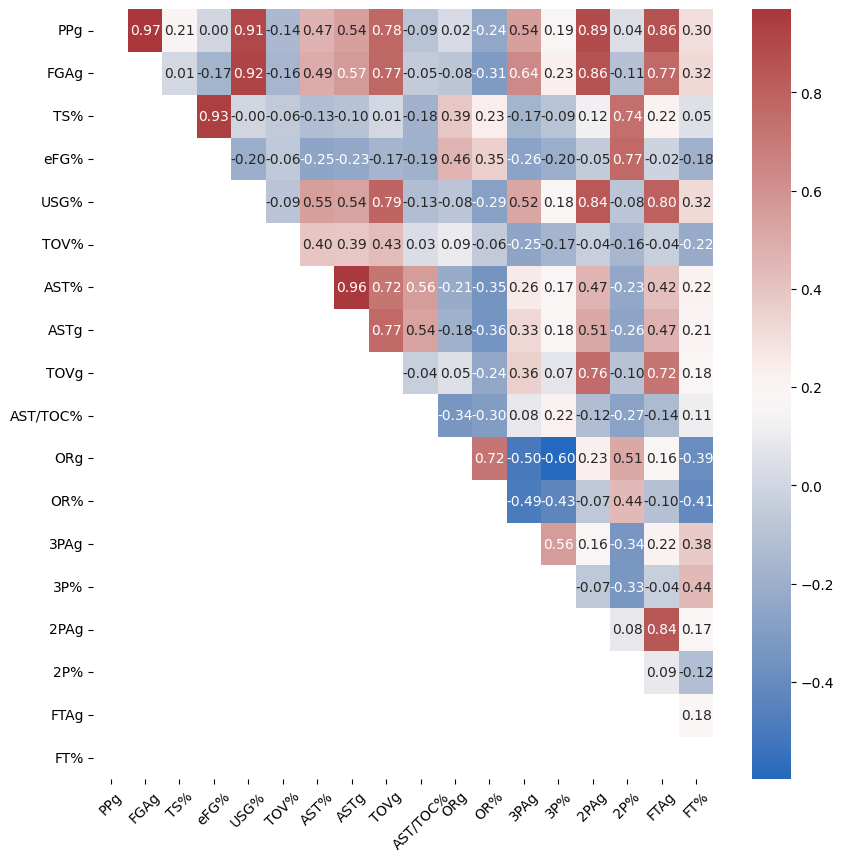

In [272]:
corr_matrix = Offensive_df.drop(columns='Position').corr()
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(data=corr_matrix, mask=mask,fmt='.2f', annot=True, cmap='vlag')
plt.xticks(rotation=45)
plt.show()

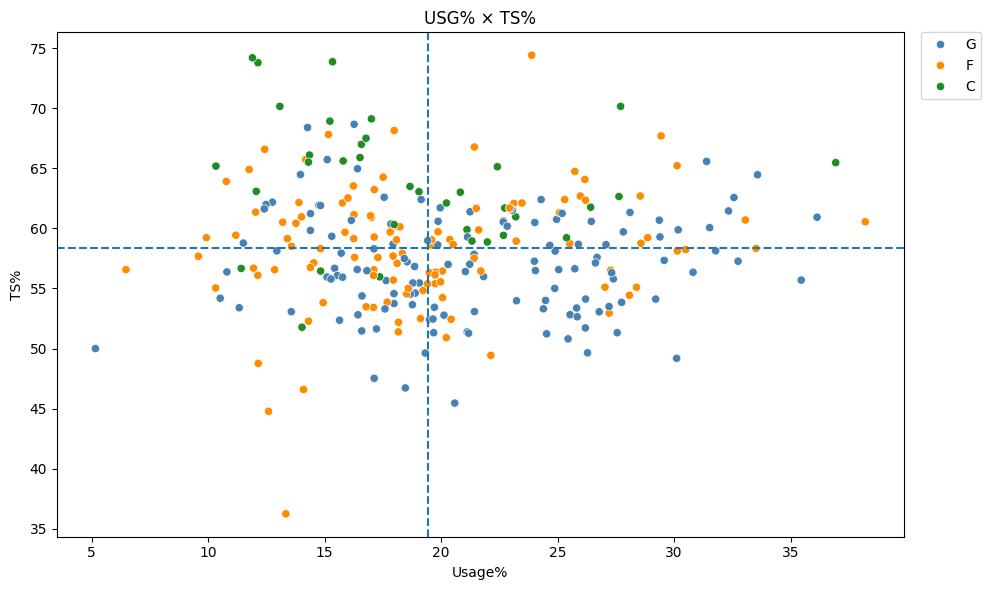

In [273]:
class_offecfive_df = Offensive_df.copy()

USG_median = class_offecfive_df['USG%'].median()
TS_mean = class_offecfive_df['TS%'].mean()

class_offecfive_df['USG_class'] = np.where(class_offecfive_df['USG%']>=USG_median, 'High_USG', 'Low_USG')
class_offecfive_df['TS_class'] = np.where(class_offecfive_df['TS%']>=TS_mean, 'High_TS', 'Low_TS')

class_offecfive_df['Quadrant'] = (class_offecfive_df['USG_class']+' & '+class_offecfive_df['TS_class'])

colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=class_offecfive_df, x='USG%', y='TS%', hue='Position', hue_order=['G', 'F', 'C'], palette=colors)
ax.axvline(USG_median, ls='--')
ax.axhline(TS_mean,  ls='--')
ax.set_xlabel('Usage%')
ax.set_ylabel('TS%')
ax.set_title('USG% × TS%')
ax.legend(bbox_to_anchor=(1.02, 1),    # 右上角外偏
          loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

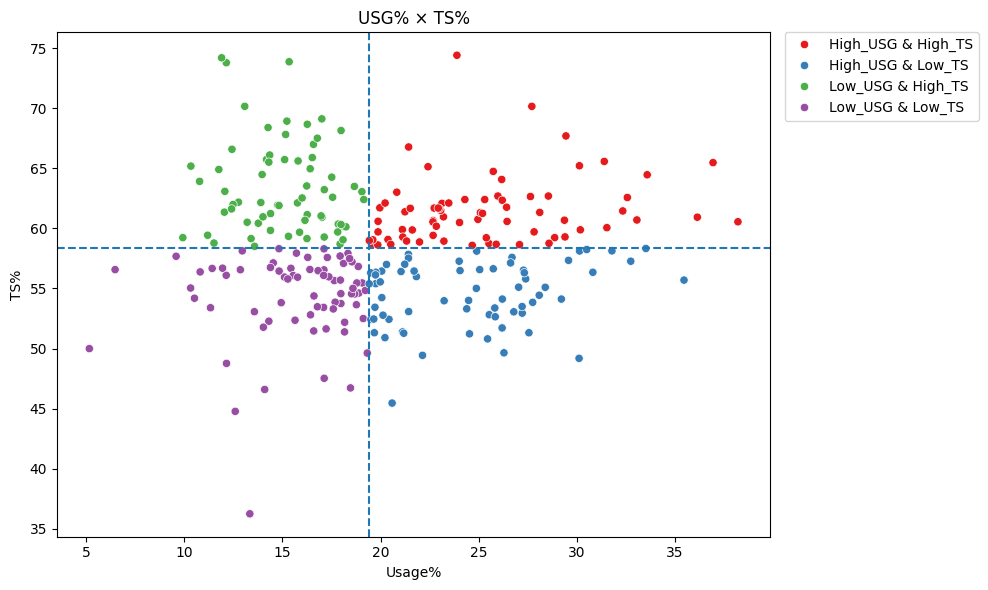

In [274]:
class_offecfive_df = Offensive_df.copy()

USG_median = class_offecfive_df['USG%'].median()
TS_mean = class_offecfive_df['TS%'].mean()

class_offecfive_df['USG_class'] = np.where(class_offecfive_df['USG%']>=USG_median, 'High_USG', 'Low_USG')
class_offecfive_df['TS_class'] = np.where(class_offecfive_df['TS%']>=TS_mean, 'High_TS', 'Low_TS')

class_offecfive_df['Quadrant'] = (class_offecfive_df['USG_class']+' & '+class_offecfive_df['TS_class'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=class_offecfive_df, x='USG%', y='TS%', hue='Quadrant', palette='Set1')
ax.axvline(USG_median, ls='--')
ax.axhline(TS_mean,  ls='--')
ax.set_xlabel('Usage%')
ax.set_ylabel('TS%')
ax.set_title('USG% × TS%')
ax.legend(bbox_to_anchor=(1.02, 1),    # 右上角外偏
          loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

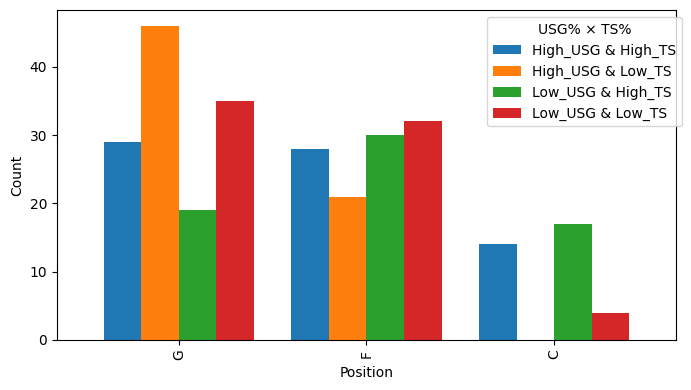

In [275]:
table = pd.crosstab(class_offecfive_df['Position'], 
                    class_offecfive_df['Quadrant']).reindex(['G','F','C'])

table[['High_USG & High_TS','High_USG & Low_TS',
       'Low_USG & High_TS','Low_USG & Low_TS']].plot(kind='bar', figsize=(7,4), width=0.8)

plt.ylabel('Count')
plt.xlabel('Position')
plt.legend(title='USG% × TS%', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

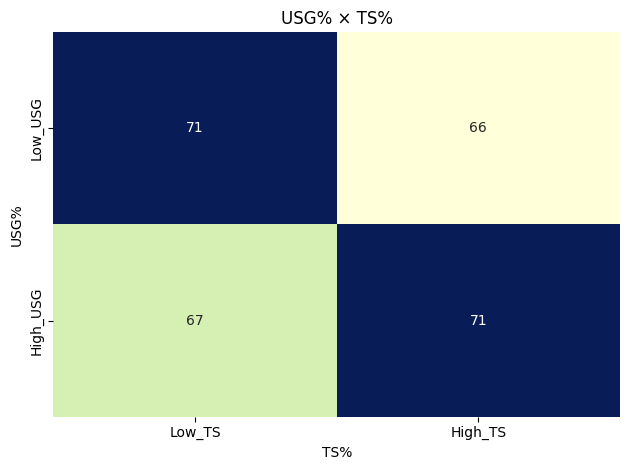

In [276]:
table_2x2 = pd.crosstab(class_offecfive_df['USG_class'],
                        class_offecfive_df['TS_class'],margins=False).reindex(index=['Low_USG', 'High_USG'], 
                                                                              columns=['Low_TS', 'High_TS'])

sns.heatmap(table_2x2, annot=True, cmap='YlGnBu', fmt='g', cbar=False)

plt.xlabel('TS%')
plt.ylabel('USG%')
plt.title('USG% × TS%')
plt.tight_layout()
plt.show()


In [277]:
class_offecfive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Position   275 non-null    object 
 1   PPg        275 non-null    float64
 2   FGAg       275 non-null    float64
 3   TS%        275 non-null    float64
 4   eFG%       275 non-null    float64
 5   USG%       275 non-null    float64
 6   TOV%       275 non-null    float64
 7   AST%       275 non-null    float64
 8   ASTg       275 non-null    float64
 9   TOVg       275 non-null    float64
 10  AST/TOC%   275 non-null    float64
 11  ORg        275 non-null    float64
 12  OR%        275 non-null    float64
 13  3PAg       275 non-null    float64
 14  3P%        275 non-null    float64
 15  2PAg       275 non-null    float64
 16  2P%        275 non-null    float64
 17  FTAg       275 non-null    float64
 18  FT%        275 non-null    float64
 19  USG_class  275 non-null    object 
 20  TS_class  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

X = class_offecfive_df.drop(columns=['USG_class', 'TS_class', 'Quadrant', 'USG%', 'TS%',])
y = class_offecfive_df['Quadrant']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['PPg', 'FGAg', 'ASTg', 'TOVg', 'AST/TOC%', '3PAg', '3P%', '2PAg', '2P%', 'FTAg', 'FT%',
            'eFG%', 'TOV%', 'AST%', 'ORg', 'OR%']
cat_cols  = ['Position']

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
                                               ('cat', OneHotEncoder(drop='first'), cat_cols)])

In [279]:
lrc = Pipeline(steps=[('prep', preprocessor), 
                             ('lrc',  LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42))])

lrc.fit(X_train, y_train)
y_pred_lrc = lrc.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lrc))

=== Logistic Regression ===
                    precision    recall  f1-score   support

High_USG & High_TS       0.80      0.86      0.83        14
 High_USG & Low_TS       1.00      0.79      0.88        14
 Low_USG & High_TS       0.83      0.77      0.80        13
  Low_USG & Low_TS       0.76      0.93      0.84        14

          accuracy                           0.84        55
         macro avg       0.85      0.84      0.84        55
      weighted avg       0.85      0.84      0.84        55



In [280]:
rfc = Pipeline(steps=[('prep', preprocessor),('rfc',  RandomForestClassifier(n_estimators=300, 
                                                                             max_depth=None, 
                                                                             class_weight='balanced',
                                                                             random_state=42))])
rfc.fit(X_train, y_train)
y_pred_rf = rfc.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
                    precision    recall  f1-score   support

High_USG & High_TS       0.92      0.79      0.85        14
 High_USG & Low_TS       0.91      0.71      0.80        14
 Low_USG & High_TS       0.77      0.77      0.77        13
  Low_USG & Low_TS       0.63      0.86      0.73        14

          accuracy                           0.78        55
         macro avg       0.81      0.78      0.79        55
      weighted avg       0.81      0.78      0.79        55



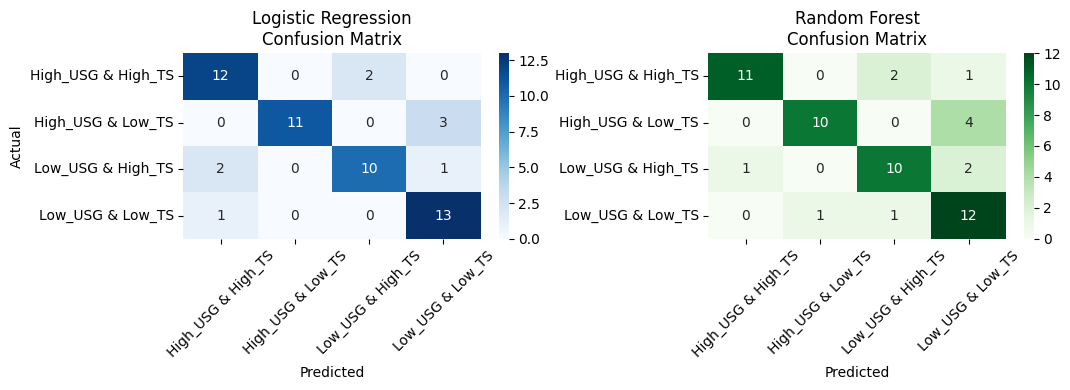

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

cm_lrc = confusion_matrix(y_test, y_pred_lrc, labels=lrc.classes_)
sns.heatmap(cm_lrc, annot=True, fmt='d', cmap='Blues',
            xticklabels=lrc.classes_, yticklabels=lrc.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rfc.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rfc.classes_, yticklabels=rfc.classes_, ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

In [282]:
results_lrc = pd.DataFrame({'Actual':y_test, 'Predicted': y_pred_lrc}, index=y_test.index)

mis_idx = results_lrc.index[results_lrc['Actual'] != results_lrc['Predicted']]

aux_cols = ['Player_Name', 'Position']
aux_info = data.loc[mis_idx, aux_cols]

mis_results_lrc_df = (pd.concat([aux_info, results_lrc.loc[mis_idx]], axis=1).reset_index(drop=True))

results_rf = pd.DataFrame({'Actual':y_test, 'Predicted': y_pred_rf}, index=y_test.index)

mis_idx = results_rf.index[results_rf['Actual'] != results_rf['Predicted']]

aux_cols = ['Player_Name', 'Position']
aux_info = data.loc[mis_idx, aux_cols]

mis_results_rf_df = (pd.concat([aux_info, results_rf.loc[mis_idx]], axis=1).reset_index(drop=True))

the_same = pd.merge(mis_results_lrc_df, mis_results_rf_df)

print(f"Logistic Regression 共有 {len(mis_results_lrc_df)} 筆分類錯誤：\n")
print(mis_results_lrc_df,'\n')
print('-------------------------------------------------------')
print(f"Random Forest 共有 {len(mis_results_rf_df)} 筆分類錯誤：\n")
print(mis_results_rf_df,'\n')
print('-------------------------------------------------------')
print(f'都被分錯的球員是: \n')
print(the_same['Player_Name'])

Logistic Regression 共有 9 筆分類錯誤：

        Player_Name Position              Actual           Predicted
0     Jose Alvarado       PG   High_USG & Low_TS    Low_USG & Low_TS
1   Harrison Barnes       SF   Low_USG & High_TS  High_USG & High_TS
2  Donte DiVincenzo       SG   High_USG & Low_TS    Low_USG & Low_TS
3  Patrick Williams       PF    Low_USG & Low_TS  High_USG & High_TS
4    Troy Brown Jr.       SF   High_USG & Low_TS    Low_USG & Low_TS
5  Josh Christopher       SG  High_USG & High_TS   Low_USG & High_TS
6      Terance Mann       SG   Low_USG & High_TS    Low_USG & Low_TS
7     Jeremy Sochan        F   Low_USG & High_TS  High_USG & High_TS
8        Cam Thomas       SG  High_USG & High_TS   Low_USG & High_TS 

-------------------------------------------------------
Random Forest 共有 12 筆分類錯誤：

         Player_Name Position              Actual           Predicted
0      Jose Alvarado       PG   High_USG & Low_TS    Low_USG & Low_TS
1    Harrison Barnes       SF   Low_USG & High_TS  

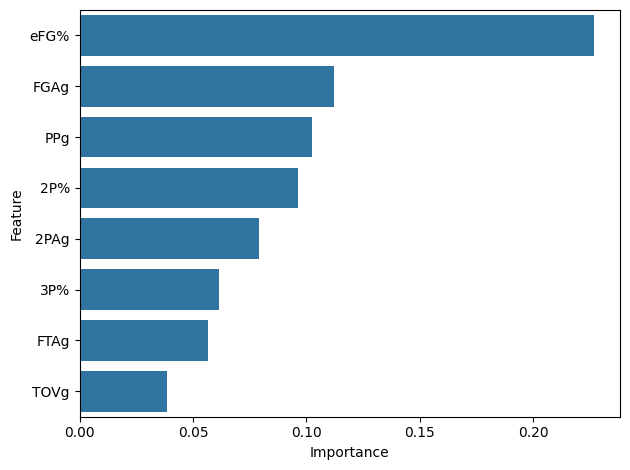

In [283]:
rf_model = rfc.named_steps['rfc']

importances = rf_model.feature_importances_

feature_names_num = preprocessor.named_transformers_['num'].get_feature_names_out(num_cols)
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

# 合併
feature_names = np.concatenate([feature_names_num, feature_names_cat])

importance_df = (pd.DataFrame({'Feature': feature_names,
                               'Importance': importances}).sort_values('Importance', ascending=False).reset_index(drop=True))


sns.barplot(data=importance_df.head(8), x='Importance', y='Feature')
plt.tight_layout()
plt.show()


In [ ]:
first_tree = rf_model.estimators_[0] # 取第0棵

feature_names = list(feature_names_num) + list(feature_names_cat)

# plt.figure(figsize=(22, 12), dpi=120)
# plot_tree(first_tree, feature_names=feature_names, class_names=rf_model.classes_.tolist(), 
#           filled=True, rounded=True, max_depth=3, fontsize=10) # 若想全深度可移除, 最深到8
# plt.tight_layout()
# plt.show()


In [286]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

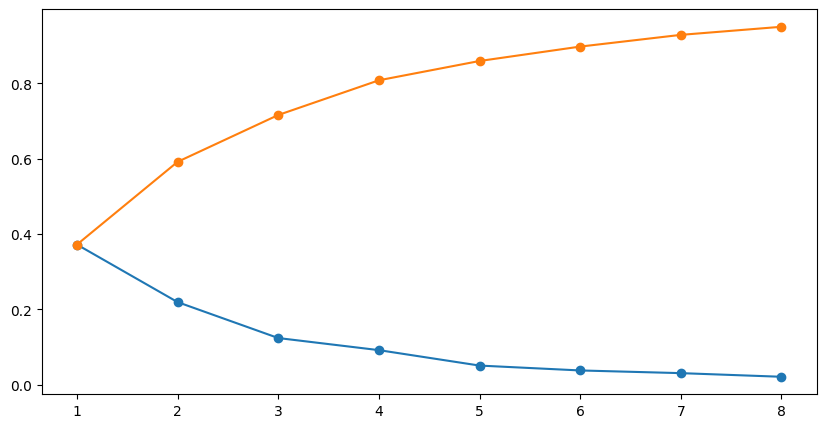

In [287]:
scaler = StandardScaler()
per_df_scaled = scaler.fit_transform(Offensive_df.drop(columns=['Position']))
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(per_df_scaled)
# pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])

explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', label='explined variance')
plt.plot(range(1, len(cum_explained_variance)+1), cum_explained_variance, marker='o', label='cumulative explained variance')
plt.show()

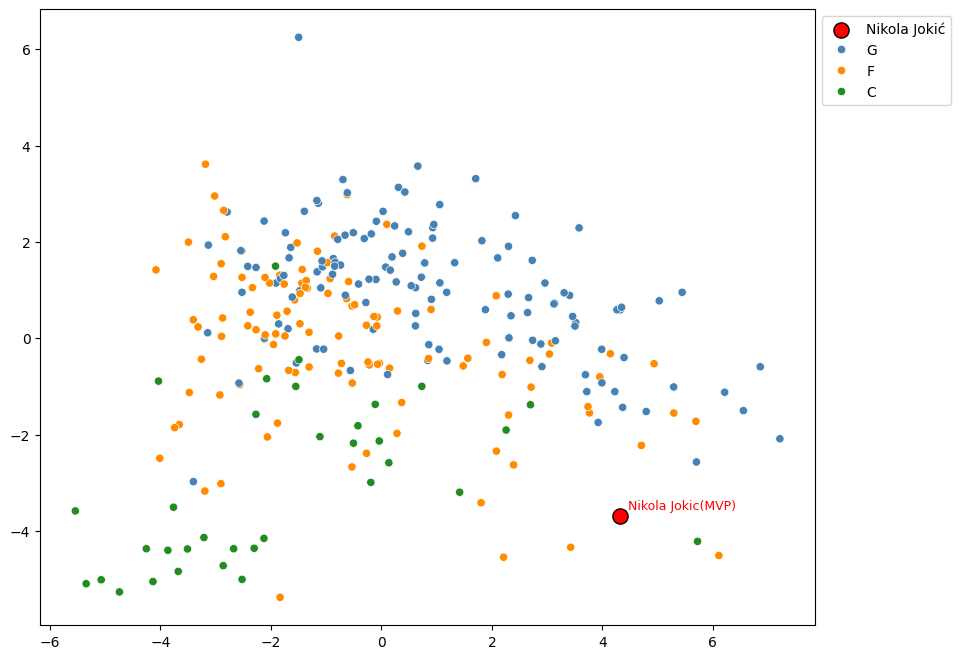

In [288]:
jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.figure(figsize=(10, 8))
plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_offecfive_df['Position'], hue_order=positions, palette=colors)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

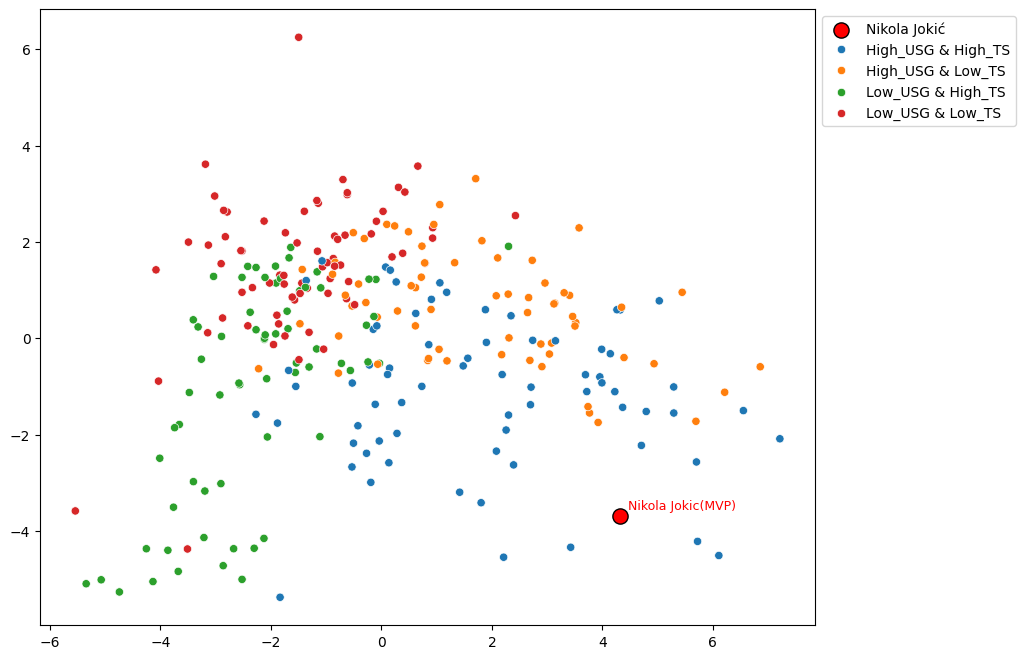

In [289]:
jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.figure(figsize=(10, 8))
plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_offecfive_df['Quadrant'])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [290]:
# loadings = pd.DataFrame(
#     data=pca.components_.T,
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)],
#     index=Offensive_df.drop(columns='Position').columns
# )

# plt.figure(figsize=(10, 5))
# loadings['PC1'].sort_values().plot(kind='barh', color='steelblue')
# plt.title('PCA Loading — PC1')
# plt.xlabel('Loading Value')
# plt.ylabel('Feature')
# plt.grid(True, axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

In [291]:
# plt.figure(figsize=(10, 5))
# loadings['PC2'].sort_values().plot(kind='barh', color='steelblue')
# plt.title('PCA Loading — PC2')
# plt.xlabel('Loading Value')
# plt.ylabel('Feature')
# plt.grid(True, axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()
